Importamos las librerias necesarias de ahora, para cargar los datos.

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.describe()

,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


In [6]:
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

In [7]:
df = df.rename(columns={'v1': 'label', 'v2': 'Text'})
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

In [8]:
df.head()

,label,Text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['Text'], df['label_enc'], test_size=0.2, random_state=42)

In [10]:
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

In [11]:
X_train

1978    Reply to win ÃÂ£100 weekly! Where will the 20...
3989    Hello. Sort of out in town already. That . So ...
3935     How come guoyang go n tell her? Then u told her?
4078    Hey sathya till now we dint meet not even a si...
4086    Orange brings you ringtones from all time Char...
                              ...                        
3772    Hi, wlcome back, did wonder if you got eaten b...
5191                               Sorry, I'll call later
5226        Prabha..i'm soryda..realy..frm heart i'm sory
5390                           Nt joking seriously i told
860               Did he just say somebody is named tampa
Name: Text, Length: 4457, dtype: object

In [12]:
X_train_np

array(['Reply to win Ã\x82Â£100 weekly! Where will the 2006 FIFA World Cup be held? Send STOP to 87239 to end service',
       'Hello. Sort of out in town already. That . So dont rush home, I am eating nachos. Will let you know eta.',
       'How come guoyang go n tell her? Then u told her?', ...,
       "Prabha..i'm soryda..realy..frm heart i'm sory",
       'Nt joking seriously i told',
       'Did he just say somebody is named tampa'],
      shape=(4457,), dtype=object)

In [13]:
avg_words_len = round(
    sum(
        [len(text.split()) for text in df['Text']]) / len(df['Text']
    )
)

total_words_length = len(set(" ".join(df['Text']).split()))

In [14]:
print(f"Data Loaded. Training samples: {len(X_train_np)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")

Data Loaded. Training samples: 4457
Average words per message: 16
Approximate vocabulary size: 15686


Funciones que nos ayuda a entrenar el modelo y ha obtener metricas

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compile_and_fit(model, epochs=5):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_np, y_train_np,
        epochs=epochs,
        validation_data=(X_test_np, y_test_np)
    )
    return history

def get_metrics(model, X, y):
    y_preds = np.round(model.predict(X))
    return {
        'accuracy': accuracy_score(y, y_preds),
        'precision': precision_score(y, y_preds),
        'recall': recall_score(y, y_preds),
        'f1': f1_score(y, y_preds)
    }

Ahora hacemos tokens con TextVectorization

In [16]:
from tensorflow.keras.layers import TextVectorization
text_vec = TextVectorization(
    max_tokens=total_words_length,
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    output_sequence_length=avg_words_len
)

text_vec.adapt(X_train_np)

Modelo 1 - Dense embedding model

In [17]:
from tensorflow.keras import layers
import tensorflow as tf

input_layer = layers.Input(shape=(1,), dtype=tf.string) # Metemos Strings en el modelo
x = text_vec(input_layer) # Vectorizamos los Strings
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x) # Creamos un embedding de 128 dimensiones
x = layers.GlobalAveragePooling1D()(x) # Hacemos un promedio de los embeddings
x = layers.Dense(32, activation='relu')(x) # Capa densa de 32 neuronas
output_layer = layers.Dense(1, activation='sigmoid')(x) # Capa de salida con activación sigmoide

from tensorflow import keras

model_1 = keras.Model(input_layer, output_layer)
history_1 = compile_and_fit(model_1)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9145 - loss: 0.2641 - val_accuracy: 0.9605 - val_loss: 0.1320
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9787 - loss: 0.0794 - val_accuracy: 0.9767 - val_loss: 0.0762
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9915 - loss: 0.0392 - val_accuracy: 0.9785 - val_loss: 0.0655
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9946 - loss: 0.0231 - val_accuracy: 0.9776 - val_loss: 0.0660
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9973 - loss: 0.0152 - val_accuracy: 0.9794 - val_loss: 0.0633


Modelo 2 - BiDireccional LSTM

In [18]:
from tensorflow.keras import layers
import tensorflow as tf

input_layer = layers.Input(shape=(1,), dtype=tf.string) # Metemos Strings en el modelo
x = text_vec(input_layer) # Vectorizamos los Strings
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x) # Creamos un embedding de 128 dimensiones
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x) # Capa LSTM bidireccional con 64 unidades
x = layers.Bidirectional(layers.LSTM(64))(x) # Capa LSTM bidireccional con 64 unidades
x = layers.Dropout(0.1)(x) # Capa de Dropout con 0.1 de probabilidad
x = layers.Dense(32, activation='relu')(x) # Capa densa de 32 neuronas
output_layer = layers.Dense(1, activation='sigmoid')(x) # Capa de salida con activación sigmoide

from tensorflow import keras

model_2 = keras.Model(input_layer, output_layer)
history_2 = compile_and_fit(model_2)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9450 - loss: 0.1701 - val_accuracy: 0.9767 - val_loss: 0.0803
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9888 - loss: 0.0407 - val_accuracy: 0.9794 - val_loss: 0.0654
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9969 - loss: 0.0132 - val_accuracy: 0.9848 - val_loss: 0.0886
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9991 - loss: 0.0035 - val_accuracy: 0.9821 - val_loss: 0.1286
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9996 - loss: 0.0023 - val_accuracy: 0.9785 - val_loss: 0.1131


Ahora transfer learning con un modelo que esta preentrenado

In [19]:
import tensorflow_hub as hub

use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)

input_layer = layers.Input(shape=[], dtype=tf.string) # Metemos Strings en el modelo
embedding_Layer = layers.Lambda(lambda x: use_layer(x), output_shape=(512,))(input_layer) # Creamos un embedding con USE
x = layers.Dense(64, activation='relu')(embedding_Layer) # Capa densa de 32 neuronas
x = layers.Dropout(0.2)(x) # Capa de Dropout con 0.2 de probabilidad
output_layer = layers.Dense(1, activation='sigmoid')(x) # Capa de salida con activación sigmoide
model_3 = keras.Model(input_layer, output_layer)
history_3 = compile_and_fit(model_3)

Epoch 1/5



140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9235 - loss: 0.2939 - val_accuracy: 0.9713 - val_loss: 0.1107
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9796 - loss: 0.0813 - val_accuracy: 0.9758 - val_loss: 0.0711
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9843 - loss: 0.0563 - val_accuracy: 0.9830 - val_loss: 0.0589
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9872 - loss: 0.0464 - val_accuracy: 0.9830 - val_loss: 0.0554
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9897 - loss: 0.0385 - val_accuracy: 0.9857 - val_loss: 0.0521


Metrics of the models

In [33]:
results = {
    'Dense Embedding' : get_metrics(model_1, X_test_np, y_test_np),
    'Bi-LSTM' : get_metrics(model_2, X_test_np, y_test_np),
    'USE Embedding (Transfer Learning)' : get_metrics(model_3, X_test_np, y_test_np)
}

results_df = pd.DataFrame(results).transpose()
print("Performance Table:")
print(results_df)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Performance Table:
                                   accuracy  precision    recall        f1
Dense Embedding                    0.979372   0.970149  0.872483  0.918728
Bi-LSTM                            0.978475   0.956204  0.879195  0.916084
USE Embedding (Transfer Learning)  0.985650   0.958621  0.932886  0.945578


Ahora mostramos los resultados en plot

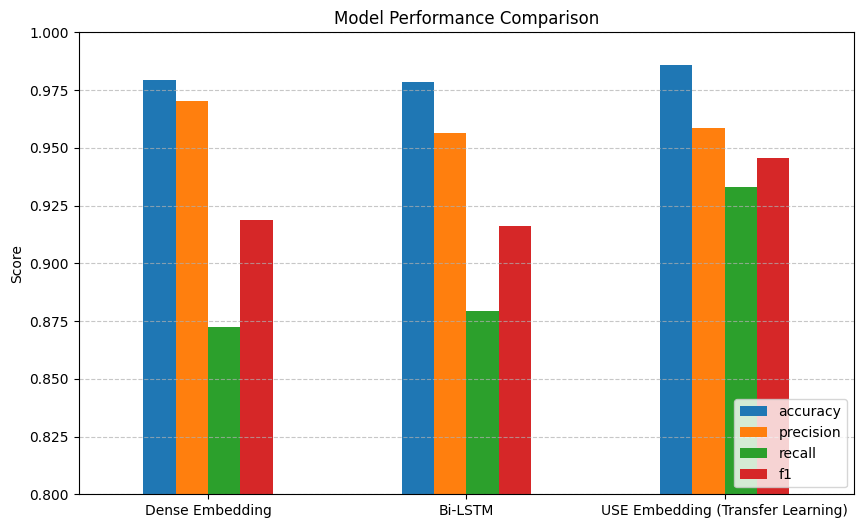

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0.8, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

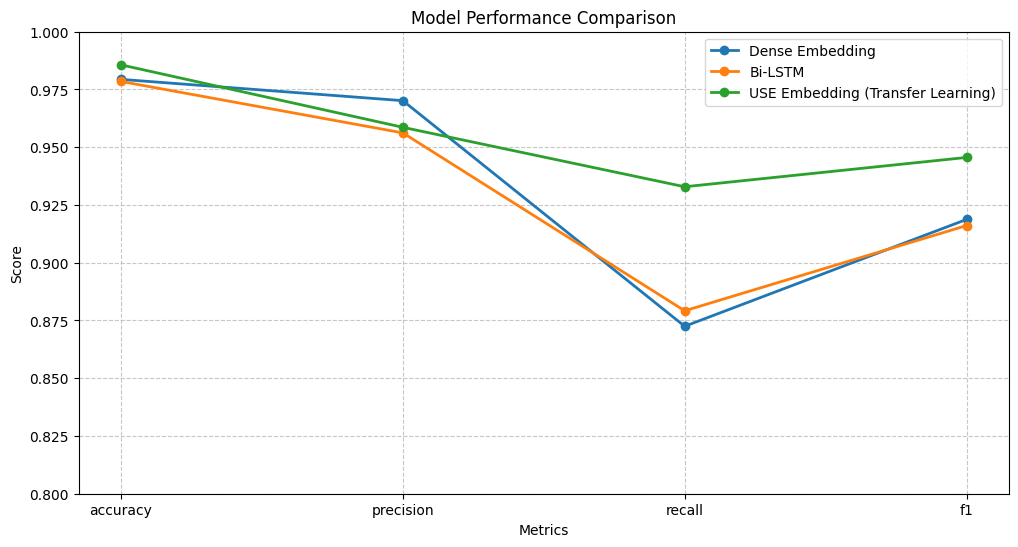

In [35]:
plt.figure(figsize=(12, 6))

for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Comparison")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.8, 1.0)
plt.legend()